This project develops an Artificial Neural Network (ANN)–based classification model to predict the likelihood of diabetes using the PIMA diabetes dataset. The model learns complex nonlinear relationships between medical diagnostic features such as glucose level, blood pressure, BMI, insulin level, and age to accurately identify diabetes risk.

The implementation demonstrates end-to-end machine learning workflow including data preprocessing, feature scaling, neural network architecture design, model training, and performance evaluation. Built using PyTorch, the project highlights how deep learning techniques can be applied to healthcare tabular data for predictive analytics and medical decision support.

In [ ]:
import pandas as pd
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Data Preprocessing

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
import seaborn as sns
import numpy as np

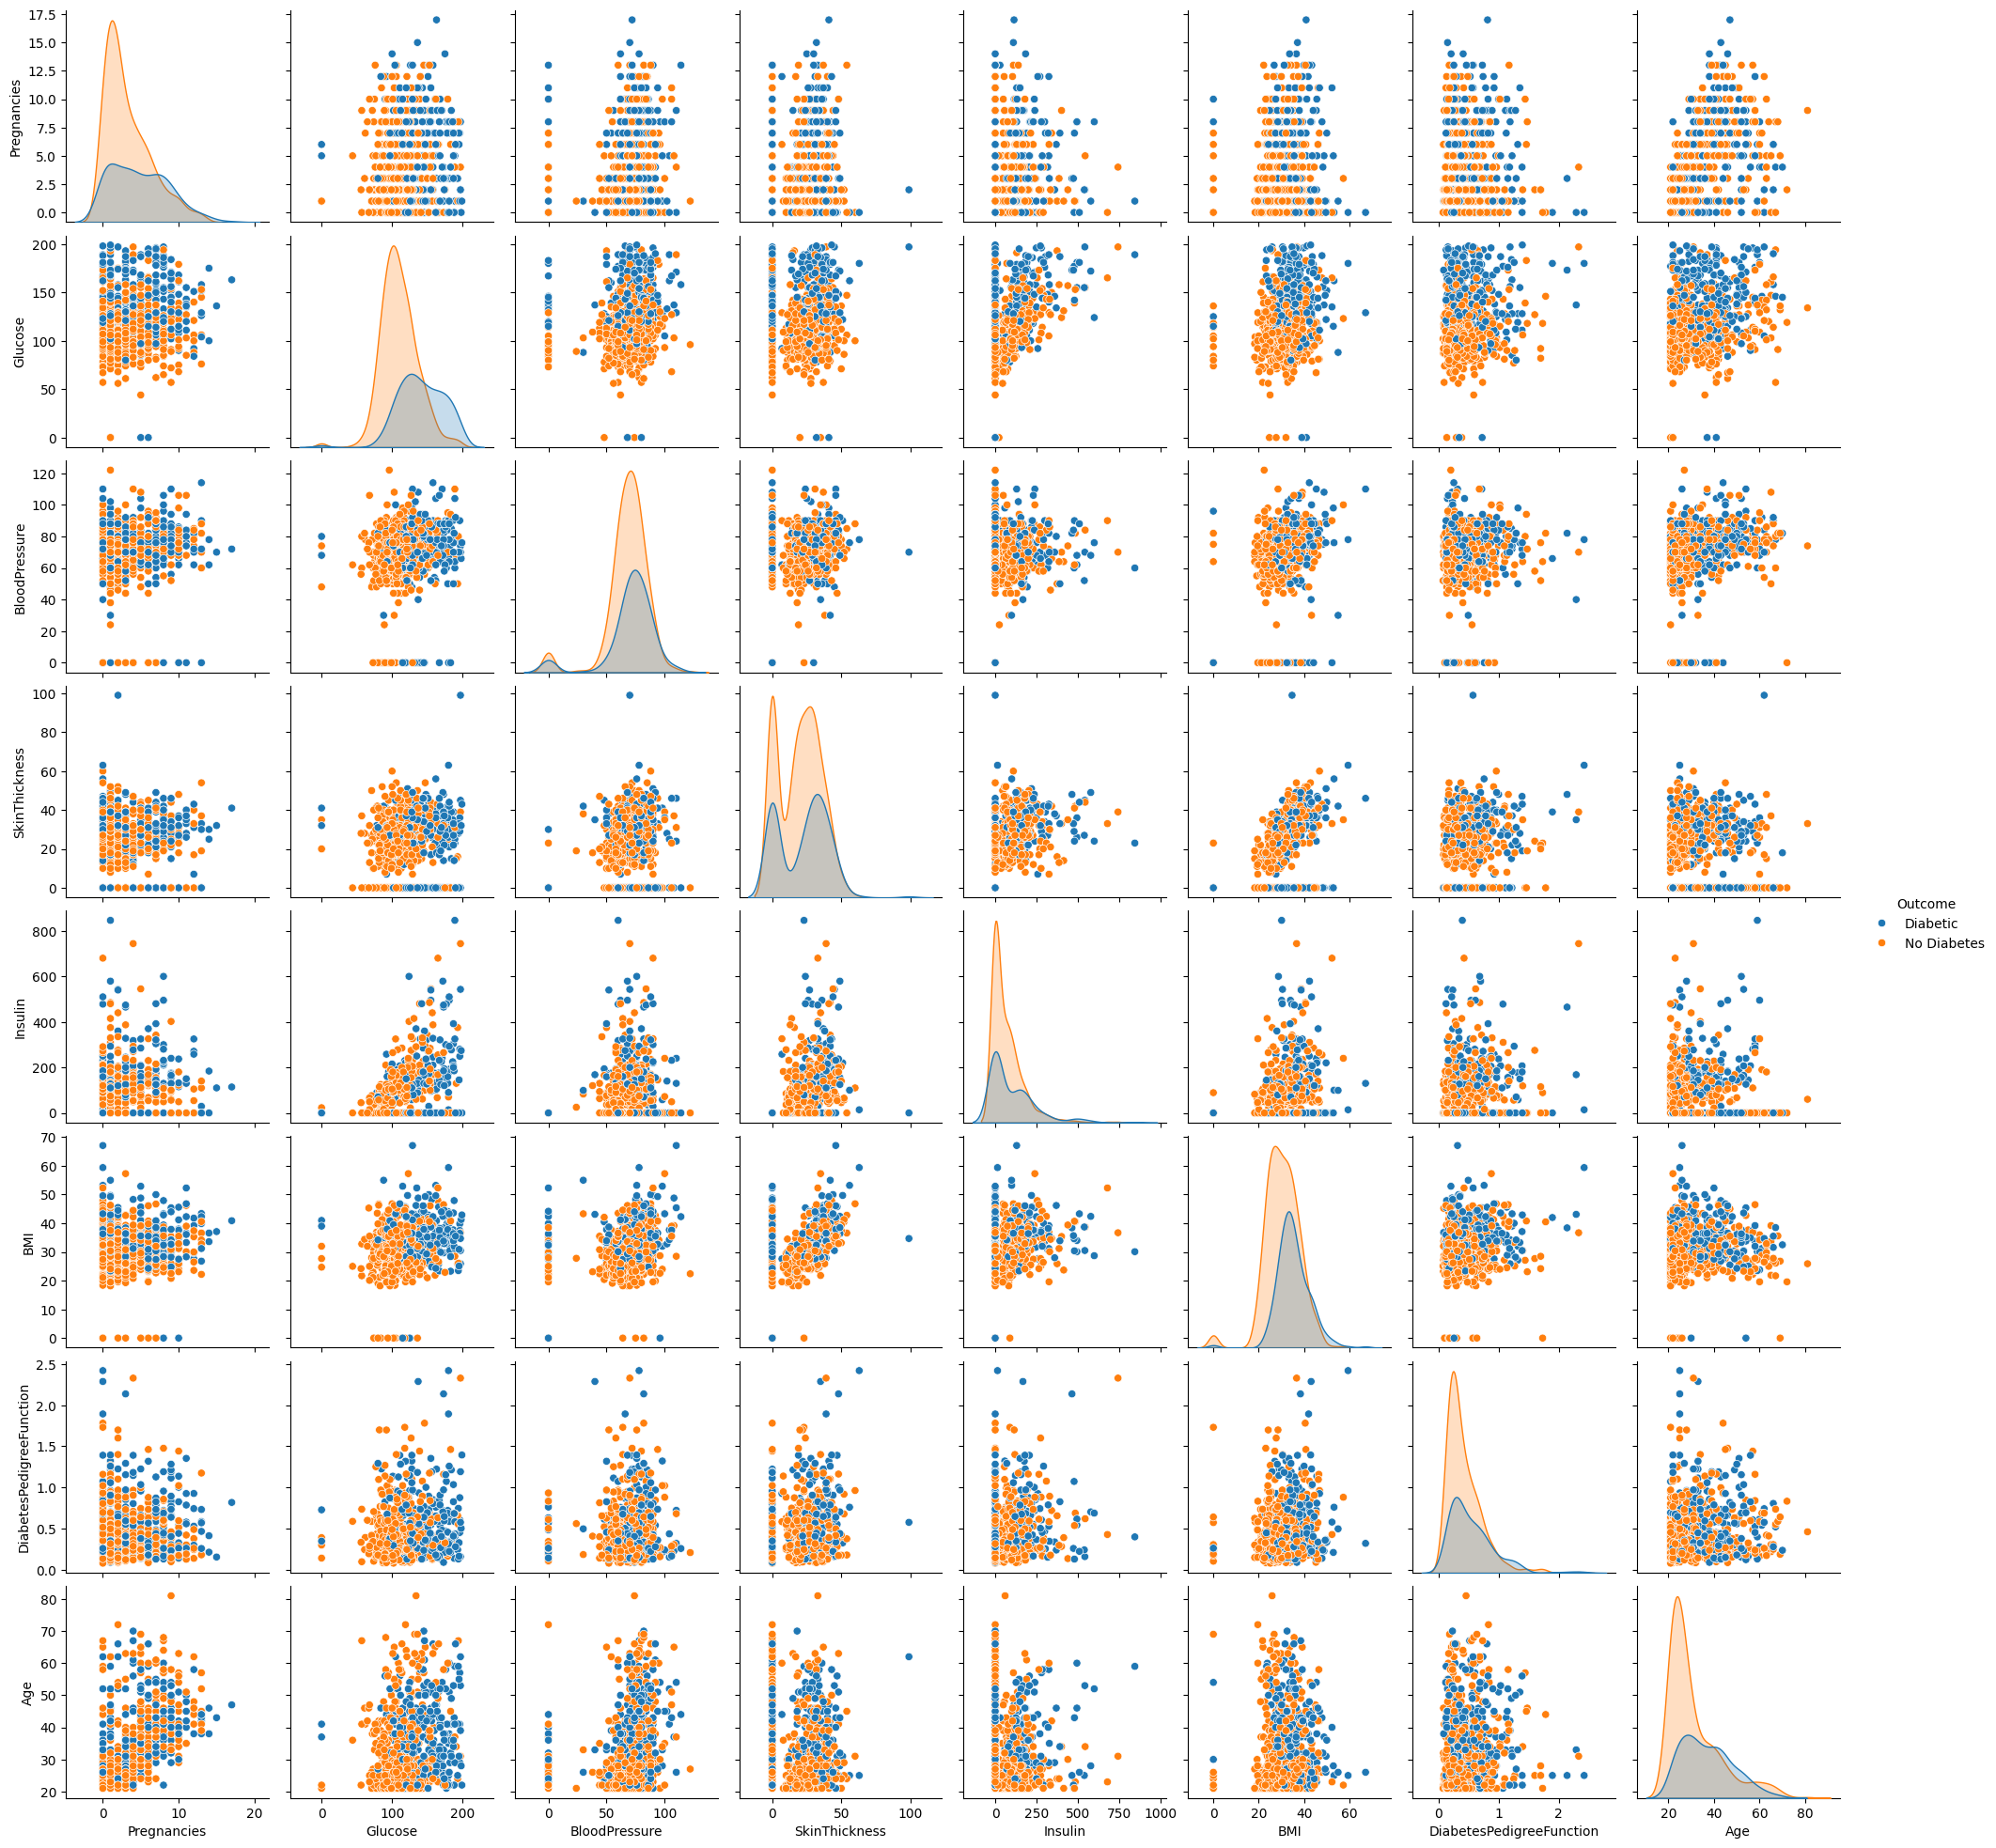

In [ ]:
df['Outcome']= np.where(df['Outcome']==1, 'Diabetic', 'No Diabetes')
sns.pairplot(df, hue ="Outcome")

In [ ]:
X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =0.2, random_state=0)

Importing Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

Creating Tensors

In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

/tmp/ipython-input-2947476391.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.float32)
/tmp/ipython-input-2947476391.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test, dtype=torch.float32)


Craeting Model

In [ ]:
class ANN_Model(nn.Module):
    def __init__(self, input_feature=8, hidden1 = 20, hidden2 = 20, out_feature=2):
        super().__init__()
        self.f_connected1 = nn.Linear(input_feature, hidden1)
        self.f_connected2 = nn.Linear(hidden1, hidden2)
        self.out = nn.Linear(hidden2, out_feature)

    def forward(self, x):
      x = F.relu(self.f_connected1(x))
      x = F.relu(self.f_connected2(x))
      x = self.out(x)
      return x


Instantiate ANN_model

In [ ]:
torch.manual_seed=20
model = ANN_Model()

In [ ]:
for param in model.parameters():
    print(param)

Parameter containing:
tensor([[ 1.9494e-01, -3.1778e-02, -1.5803e-01,  2.6486e-01,  2.0077e-01,
         -5.5849e-02,  2.1798e-01,  5.6336e-02],
        [-1.7258e-02,  1.8138e-01,  1.2092e-01, -3.1952e-01,  2.4028e-01,
         -1.1906e-01,  6.1647e-02,  2.5235e-01],
        [-2.7562e-01, -7.0310e-02,  2.2982e-01, -2.3876e-01,  7.0431e-02,
          1.0660e-01, -2.1639e-01,  2.0959e-01],
        [ 2.9903e-02, -5.0752e-02, -3.4016e-01,  3.3643e-01, -1.5878e-01,
          1.6170e-01,  2.1171e-01,  2.6716e-01],
        [ 2.1902e-01, -3.4614e-01, -2.6135e-01, -3.7760e-02,  1.3251e-01,
         -1.3104e-01,  3.3765e-01, -2.4297e-01],
        [ 1.1918e-01, -1.0087e-01,  2.1487e-01, -1.9237e-01, -1.7904e-02,
         -1.7713e-01,  2.1166e-01, -4.2472e-02],
        [-2.1322e-01, -3.0717e-02,  2.2983e-01,  3.4378e-01,  2.4890e-01,
         -1.1886e-01, -1.6522e-01, -3.1101e-01],
        [ 2.1154e-01, -2.6643e-01,  4.9560e-02, -1.7607e-01, -2.5552e-01,
         -3.4143e-01, -1.2631e-01, -3.1920e

Backward Propogation
1. Define Loss function
2. Define Optimizer

In [ ]:
loss_function = nn.CrossEntropyLoss() ##for multiclass classification
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [ ]:
epochs =500
final_losses =[]

for i in range(epochs):
  i =i+1
  y_pred = model.forward(X_train)
  loss = loss_function(y_pred, y_train)
  final_losses.append(loss.item())
  if i%10 == 1:
    print("Epoch number: {} and the loss : {}".format(i, loss.item()))
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()



Epoch number: 1 and the loss : 0.405713826417923
Epoch number: 11 and the loss : 0.4009822905063629
Epoch number: 21 and the loss : 0.40062057971954346
Epoch number: 31 and the loss : 0.3954019546508789
Epoch number: 41 and the loss : 0.3922628164291382
Epoch number: 51 and the loss : 0.3894806206226349
Epoch number: 61 and the loss : 0.3872036635875702
Epoch number: 71 and the loss : 0.39767980575561523
Epoch number: 81 and the loss : 0.39663150906562805
Epoch number: 91 and the loss : 0.40311306715011597
Epoch number: 101 and the loss : 0.3863638937473297
Epoch number: 111 and the loss : 0.3843441307544708
Epoch number: 121 and the loss : 0.37931132316589355
Epoch number: 131 and the loss : 0.37638190388679504
Epoch number: 141 and the loss : 0.37462061643600464
Epoch number: 151 and the loss : 0.43104419112205505
Epoch number: 161 and the loss : 0.38316044211387634
Epoch number: 171 and the loss : 0.373951256275177
Epoch number: 181 and the loss : 0.37870800495147705
Epoch number: 1

Plot the Loss function

Text(0.5, 0, 'Epoch')

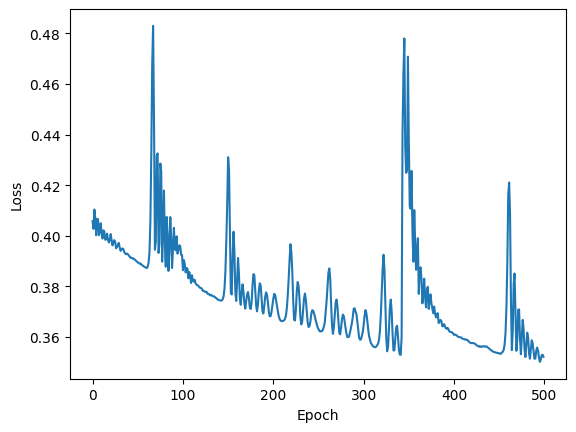

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(range(epochs), final_losses)
plt.ylabel('Loss')
plt.xlabel('Epoch')

Prediction on X_test data:

In [ ]:
predictions = []
with torch.no_grad():
  for i,data in enumerate(X_test):
    y_pred = model(data)
    predictions.append(y_pred.argmax().item())

In [ ]:
predictions

[1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0]

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions)
cm


array([[84, 23],
       [18, 29]])

Text(95.72222222222221, 0.5, 'Predicted Values')

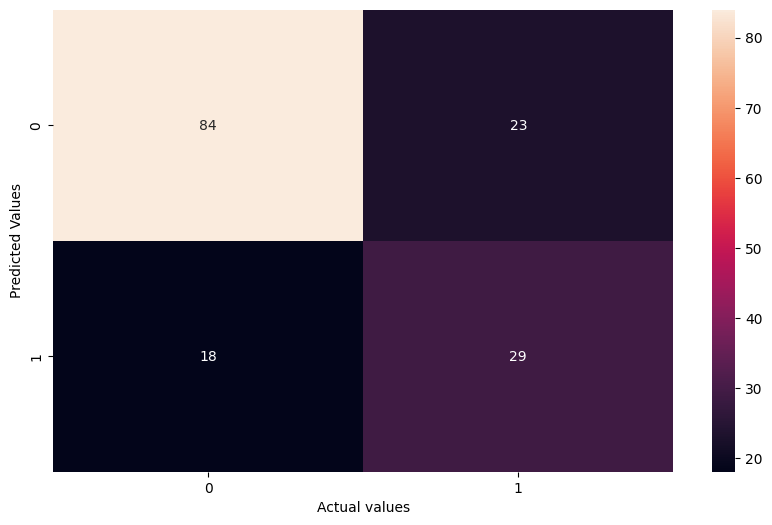

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True)
plt.xlabel('Actual values')
plt.ylabel('Predicted Values')

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, predictions)

0.7337662337662337

In [ ]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


It is an imbalaced dataset and thus accuracy is not the right metric for evaluating performance!

Save the Model

In [ ]:
torch.save(model.state_dict(), 'diabetes.pt')

For Loading

In [ ]:
# Recreate the model architecture first
model = ANN_Model()

# Load the saved parameters
state_dict = torch.load('diabetes.pt')
model.load_state_dict(state_dict)


# Set the model to evaluation mode (important for inference)
model.eval()


ANN_Model(
  (f_connected1): Linear(in_features=8, out_features=20, bias=True)
  (f_connected2): Linear(in_features=20, out_features=20, bias=True)
  (out): Linear(in_features=20, out_features=2, bias=True)
)

Prediction of new data point

In [ ]:
list(df.iloc[0,:-1])

[6.0, 148.0, 72.0, 35.0, 0.0, 33.6, 0.627, 50.0]

In [ ]:
##new data
lst1 = [6.0, 130.0, 72.0, 40.0, 0.0, 25.6, 0.627, 45.0]

In [ ]:
new_data = torch.tensor(lst1, dtype=torch.float32)

In [ ]:
## predict new data:
with torch.no_grad():
  print(model(new_data))
  print(model(new_data).argmax().item())

tensor([-0.2465,  0.3276])
1
